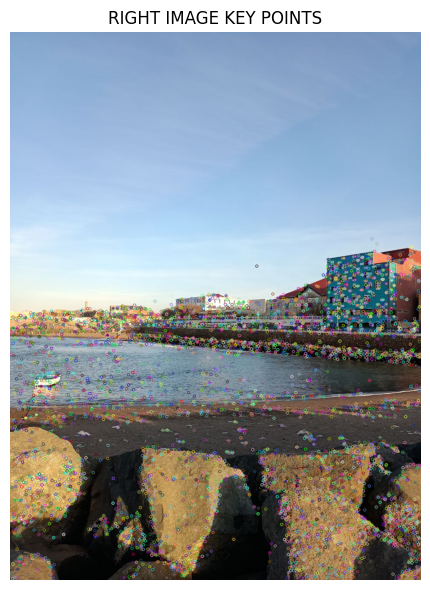

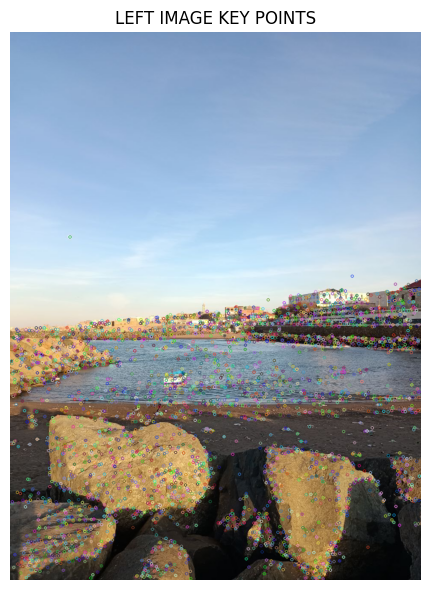

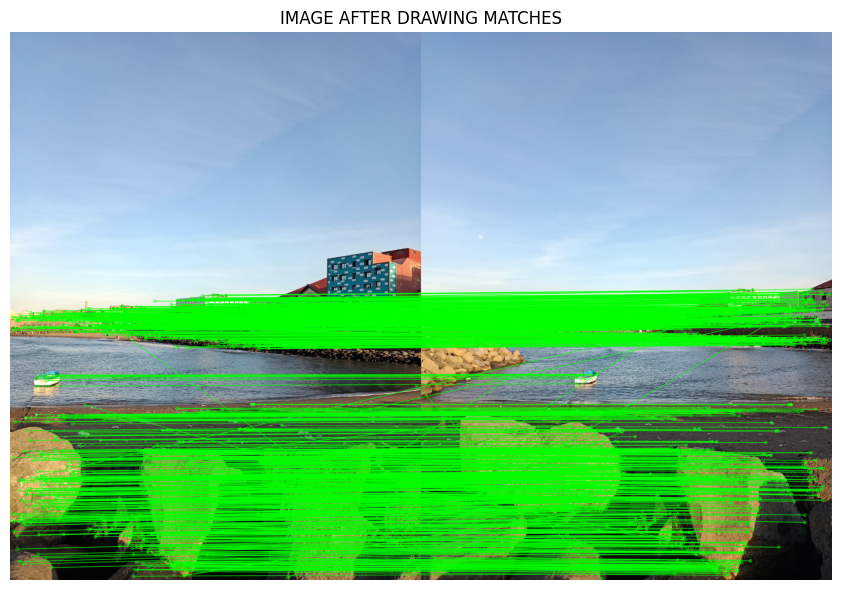

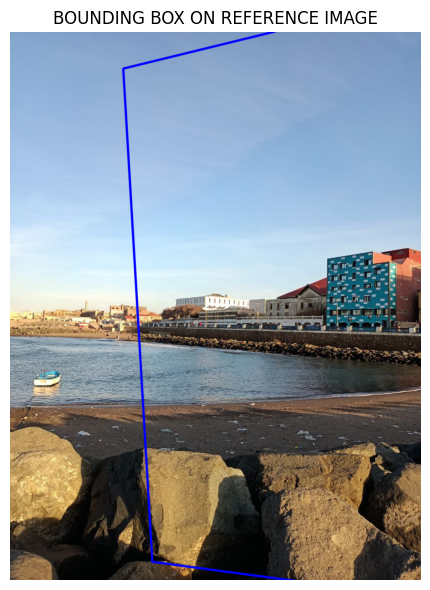

Canvas size → width: 1920, height: 1280


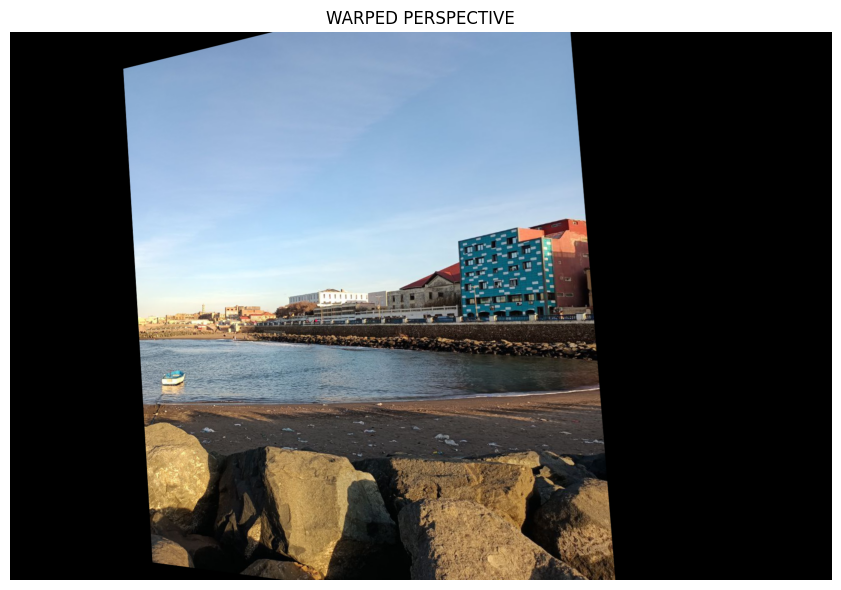

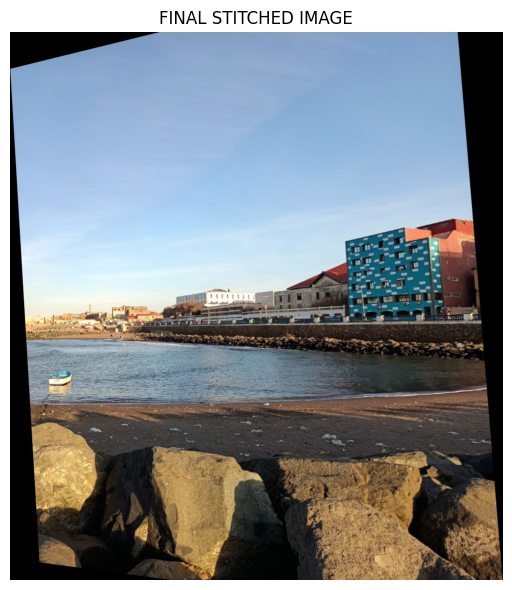

✅ Saved as STITCHED_IMAGE_CROP.jpg


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# HELPER FUNCTION — show images with matplotlib instead of cv2
# OpenCV uses BGR color format, but matplotlib expects RGB,
# so we convert before displaying
# ============================================================
def show(title, img):
    # cv2.cvtColor converts BGR → RGB so colors look correct in plt
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))       # set window size in inches
    plt.title(title)
    plt.axis('off')                   # hide x/y axis ticks
    plt.imshow(rgb)
    plt.tight_layout()
    plt.show()


# ============================================================
# STEP 1 — LOAD IMAGES
# cv2.imread loads image from disk as a NumPy array (h, w, 3)
# It stores pixels as BGR (Blue Green Red) NOT the usual RGB
# ============================================================
imgR = cv2.imread('Mid.jpg')       # this is your REFERENCE image (the one you know)
imgL = cv2.imread("Left.jpg")       # this is your QUERY image (the one you want to match/stitch)


# ============================================================
# STEP 2 — CONVERT TO GRAYSCALE
# SIFT works on intensity (brightness) not color,
# so we simplify each pixel from (B,G,R) → single brightness value
# shape goes from (h, w, 3) → (h, w)
# ============================================================
grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)


# ============================================================
# STEP 3 — CREATE SIFT DETECTOR
# SIFT = Scale Invariant Feature Transform
# It finds "interesting" points (corners, edges, blobs) in an image
# that can be recognized even if the image is:
#   - rotated
#   - scaled (zoomed in/out)
#   - slightly distorted
# ============================================================
sift = cv2.SIFT_create()


# ============================================================
# STEP 4 — DETECT KEYPOINTS AND COMPUTE DESCRIPTORS
#
# sift.detectAndCompute() returns TWO things:
#
# 1) keypoints (kpR / kpL):
#    A list of special locations found in the image
#    Each keypoint stores: position (x,y), size, angle, etc.
#
# 2) descriptors (dsR / dsL):
#    A 128-number "fingerprint" for each keypoint
#    These numbers describe what the area AROUND the keypoint looks like
#    Two matching keypoints in different images will have very similar descriptors
#
# We pass grayscale images because SIFT only needs brightness info
# ============================================================
kpR, dsR = sift.detectAndCompute(grayR, None)
kpL, dsL = sift.detectAndCompute(grayL, None)


# ============================================================
# STEP 5 — VISUALIZE KEYPOINTS
# drawKeypoints draws small circles on each detected keypoint
# ============================================================
show('RIGHT IMAGE KEY POINTS', cv2.drawKeypoints(imgR, kpR, None))
show('LEFT IMAGE KEY POINTS',  cv2.drawKeypoints(imgL, kpL, None))


# ============================================================
# STEP 6 — MATCH KEYPOINTS USING BRUTE FORCE MATCHER
#
# BFMatcher compares EVERY descriptor in imgR against EVERY
# descriptor in imgL and finds the closest ones
#
# knnMatch with k=2 returns the 2 BEST matches for each keypoint
# We need 2 so we can apply Lowe's ratio test below
# ============================================================
match   = cv2.BFMatcher()
matches = match.knnMatch(dsR, dsL, k=2)


# ============================================================
# STEP 7 — LOWE'S RATIO TEST (filter bad matches)
#
# For each keypoint in imgR, knnMatch gives us:
#   m = best match (smallest distance / most similar descriptor)
#   n = second best match
#
# If m is a TRULY good match, its distance should be much smaller than n
# The rule: only keep m if it's at least 25% better than n (ratio < 0.75)
#
# If m.distance ≈ n.distance → the match is ambiguous → discard it
# This filters out most false matches
# ============================================================
good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)


# ============================================================
# STEP 8 — DRAW MATCHES
# drawMatches places imgR and imgL side by side and draws
# lines connecting each matched keypoint pair
# ============================================================
draw_params = dict(
    matchColor      = (0, 255, 0),   # color of the match lines (green)
    singlePointColor= None,           # don't draw unmatched keypoints
    flags           = 2               # don't draw unmatched keypoints either
)

img3 = cv2.drawMatches(imgR, kpR, imgL, kpL, good, None, **draw_params)
show("IMAGE AFTER DRAWING MATCHES", img3)


# ============================================================
# STEP 9 — FIND HOMOGRAPHY
#
# A Homography is a 3x3 matrix M that describes how to
# TRANSFORM (warp) one image's perspective to match another
#
# To compute it, we need at least 4 matching point pairs
#
# src_pts: the (x,y) coordinates of good keypoints in imgR
# dst_pts: the (x,y) coordinates of their matches in imgL
#
# WHY reshape(-1, 1, 2)?
#   kp.pt gives a flat list: [(x1,y1), (x2,y2), ...]
#   findHomography requires shape (N, 1, 2):
#     -1  → NumPy auto-calculates N (number of points)
#      1  → each point is wrapped in its own dimension (OpenCV requirement)
#      2  → each point has 2 values: x and y
#
# RANSAC = Random Sample Consensus
#   Randomly picks 4 point pairs, computes a homography,
#   then checks how many OTHER pairs agree with it (inliers)
#   Repeats many times, keeps the best result
#   This makes it robust to wrong matches (outliers)
# ============================================================
MIN_MATCH_COUNT = 10

if len(good) > MIN_MATCH_COUNT:

    src_pts = np.float32([kpR[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kpL[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # M  = the 3x3 homography matrix
    # mask = which matches RANSAC considered as inliers (good ones)
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)


    # ============================================================
    # STEP 10 — DRAW BOUNDING BOX ON imgR
    # We define the 4 corners of imgR, then use perspectiveTransform
    # to find where those corners END UP in imgL's coordinate space
    # Then we draw that polygon on imgR to visualize the overlap area
    # ============================================================
    h, w = imgR.shape[:2]    # [:2] because color image shape = (h, w, 3)

    # 4 corners of imgR: top-left, bottom-left, bottom-right, top-right
    pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

    # Transform those corners using the homography matrix
    dst_box = cv2.perspectiveTransform(pts, M)

    imgR_drawn = cv2.polylines(imgR.copy(), [np.int32(dst_box)], True, 255, 3, cv2.LINE_AA)
    show("BOUNDING BOX ON REFERENCE IMAGE", imgR_drawn)

else:
    print(f"Not enough matches found: {len(good)}/{MIN_MATCH_COUNT}")


# ============================================================
# STEP 11 — WARP PERSPECTIVE (the actual stitching step)
#
# warpPerspective applies the homography M to imgR,
# stretching/rotating it so it aligns with imgL
#
# The output canvas size = combined width of both images x height
#   canvas_width  = imgL width + imgR width  (side by side)
#   canvas_height = imgL height
#
# The print below just lets you see these numbers in the terminal
# ============================================================
canvas_width  = imgL.shape[1] + imgR.shape[1]
canvas_height = imgL.shape[0]
print(f"Canvas size → width: {canvas_width}, height: {canvas_height}")

dst = cv2.warpPerspective(imgR, M, (canvas_width, canvas_height))
show("WARPED PERSPECTIVE", dst)


# ============================================================
# STEP 12 — TRIM FUNCTION (remove black borders)
#
# After warping, the empty parts of the canvas are black (all zeros)
# trim() recursively checks each of the 4 borders and removes them
#
# frame[0]     → top row    (all pixels in row 0)
# frame[-1]    → bottom row (all pixels in last row)
# frame[:, 0]  → left col   (all pixels in column 0)
# frame[:, -1] → right col  (all pixels in last column)
#
# np.sum(row) == 0 means ALL pixels in that row/col are black
# If so, slice it off and recurse until no black borders remain
#
# NUMPY SLICING EXPLAINED on arr = [[1,2,3,4,5],[6,7,8,9,10]]:
#
#  arr[-1]      → [6,7,8,9,10]          last row
#  arr[0:-1]    → [[1,2,3,4,5]]         all rows except last
#  arr[0]       → [1,2,3,4,5]           first row
#  arr[1:]      → [[6,7,8,9,10]]        all rows from index 1 onward
#  arr[:, -1]   → [5, 10]               last column of EVERY row
#  arr[:, :-1]  → [[1,2,3,4],[6,7,8,9]] all cols except last
#  arr[:, 0]    → [1, 6]                first column of EVERY row
#  arr[:, 1:]   → [[2,3,4,5],[7,8,9,10]]all cols from index 1 onward
# ============================================================
def trim(frame):
    if not np.sum(frame[0]):           # top row all black → remove it
        return trim(frame[1:])

    if not np.sum(frame[-1]):          # bottom row all black → remove it
        return trim(frame[0:-1])

    if not np.sum(frame[:, 0]):        # left column all black → remove it
        return trim(frame[:, 1:])

    if not np.sum(frame[:, -1]):       # right column all black → remove it
        return trim(frame[:, :-1])

    return frame                        # no more black borders → done!


# ============================================================
# STEP 13 — SHOW AND SAVE FINAL STITCHED IMAGE
# ============================================================
result = trim(dst)
show("FINAL STITCHED IMAGE", result)
cv2.imwrite("STITCHED_IMAGE_CROP.jpg", result)
print("✅ Saved as STITCHED_IMAGE_CROP.jpg")
